# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 40°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 685
Average Fx in the averaging interval [600:1285]: 4.751089119505128
Average Fz in the averaging interval [600:1285]: 1.1573452766214263
Maximum Fz in the plotting interval [600:None]: 2.4985555013020835 at timestep 1272
Time step where Fx drops below 0.2: 1285


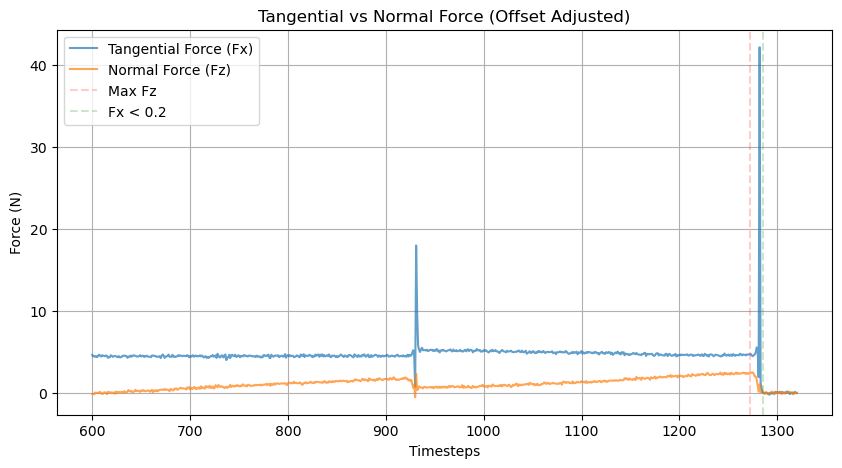

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241539.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=600, cut_2=None, avg_end=1285, offset_position='end', offset_length=30, fx_threshold=0.2)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 1596
Average Fx in the averaging interval [370:1966]: 4.954485315248781
Average Fz in the averaging interval [370:1966]: 2.8446837690539826
Maximum Fz in the plotting interval [370:None]: 5.751912434895833 at timestep 1930
Time step where Fx drops below 1: 1966


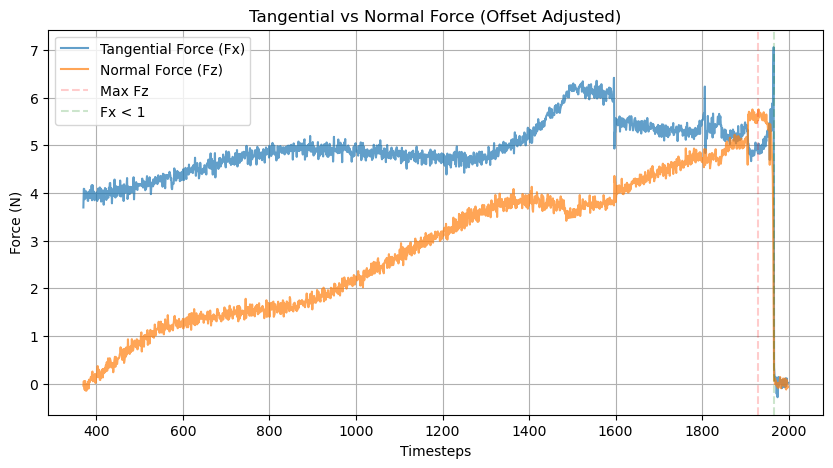

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241540.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=370, cut_2=None, avg_end=1966, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 955
Average Fx in the averaging interval [212:1167]: 3.6743420654150416
Average Fz in the averaging interval [212:1167]: 1.604460871032395
Maximum Fz in the plotting interval [212:None]: 3.68021240234375 at timestep 1163
Time step where Fx drops below 0.1: 1167


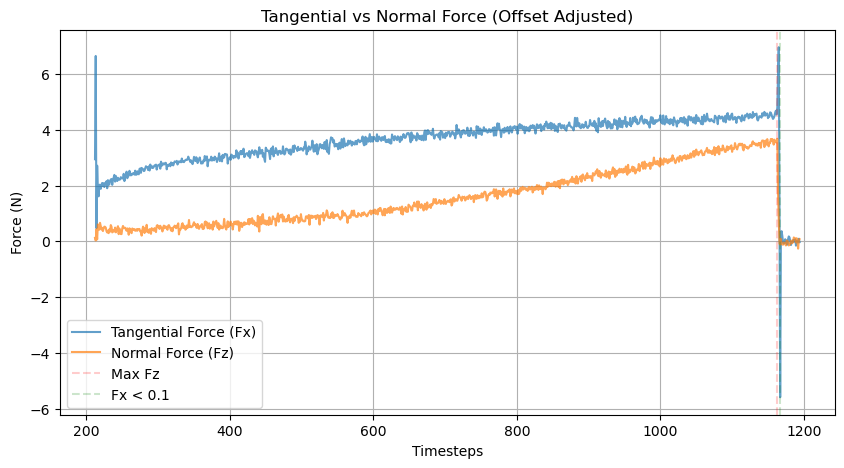

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241542.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=212, cut_2=None, avg_end=1167, offset_position='end', offset_length=15, fx_threshold=0.1)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 382
Average Fx in the averaging interval [793:1175]: 4.84980832927098
Average Fz in the averaging interval [793:1175]: 0.3596096178624018
Maximum Fz in the plotting interval [793:None]: 1.11787109375 at timestep 1144
Time step where Fx drops below 1: 1175


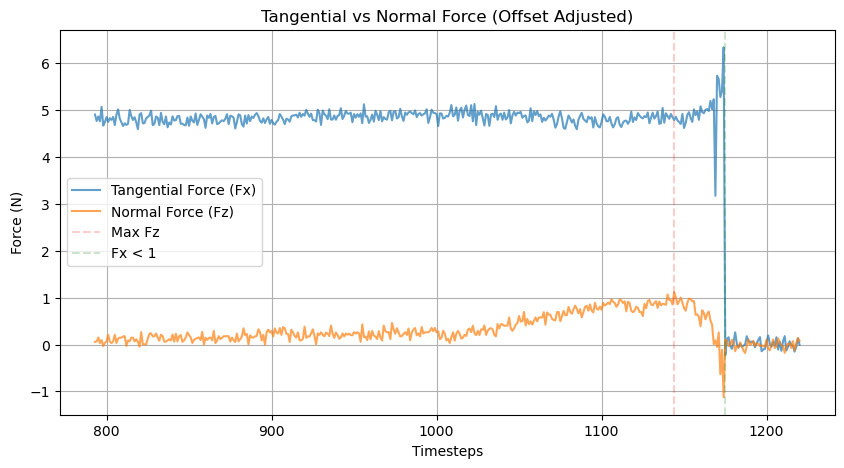

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241543.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=793, cut_2=None, avg_end=1175, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 744
Average Fx in the averaging interval [645:1389]: 4.960397326177166
Average Fz in the averaging interval [645:1389]: 1.6710686796454972
Maximum Fz in the plotting interval [645:None]: 3.24132080078125 at timestep 1374
Time step where Fx drops below 1: 775


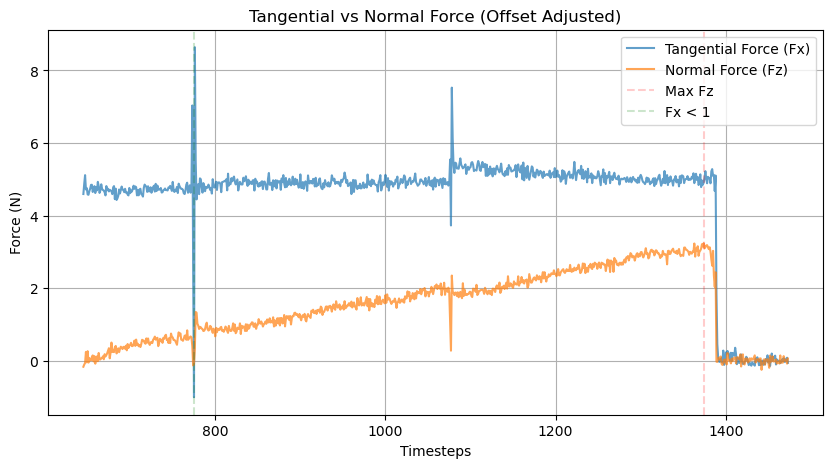

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241546.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=645, cut_2=None, avg_end=1389, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 391
Average Fx in the averaging interval [200:591]: 3.8191144144037086
Average Fz in the averaging interval [200:591]: 0.7787955125579444
Maximum Fz in the plotting interval [200:None]: 1.7482421875 at timestep 527
Time step where Fx drops below 1: 591


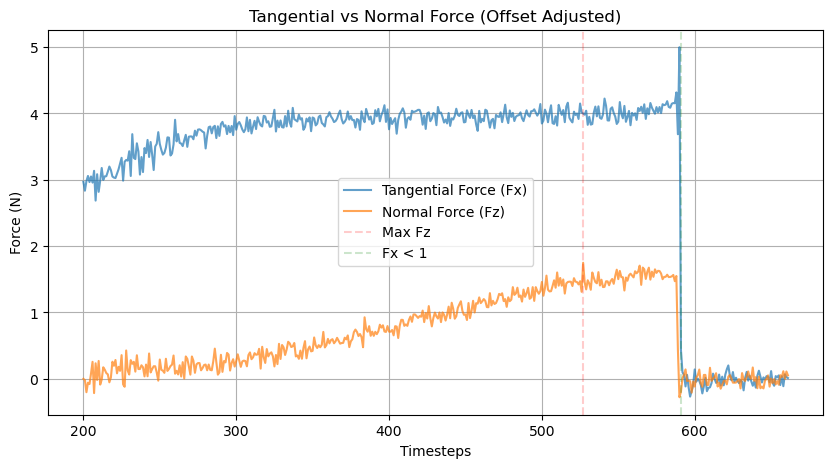

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241548.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=200, cut_2=None, avg_end=591, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 975
Average Fx in the averaging interval [370:1345]: 4.716750648694161
Average Fz in the averaging interval [370:1345]: 1.4638251827924678
Maximum Fz in the plotting interval [370:None]: 2.9018310546875 at timestep 1267
Time step where Fx drops below 1: 1345


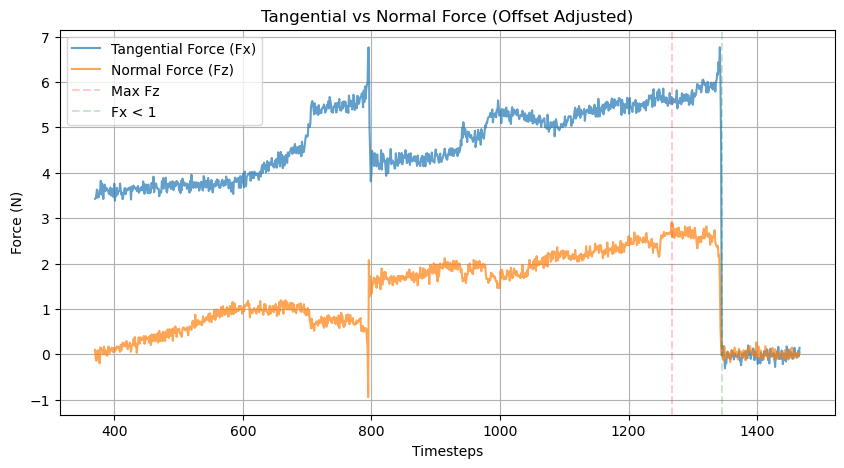

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241549.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=370, cut_2=None, avg_end=1345, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 406
Average Fx in the averaging interval [770:1176]: 4.654088577496007
Average Fz in the averaging interval [770:1176]: 1.1529967259499436
Maximum Fz in the plotting interval [770:None]: 2.5227376302083333 at timestep 1164
Time step where Fx drops below 1: 1176


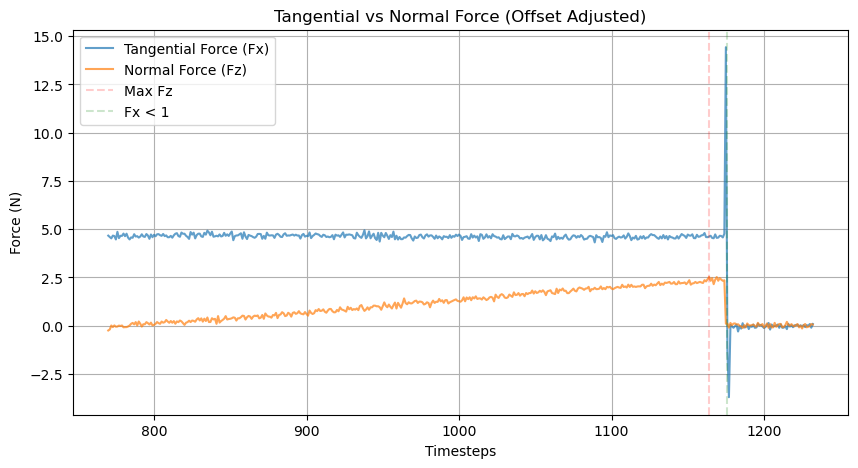

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241552.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=770, cut_2=None, avg_end=1176, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 906
Average Fx in the averaging interval [600:1506]: 4.922081998589285
Average Fz in the averaging interval [600:1506]: 1.8090346717413426
Maximum Fz in the plotting interval [600:None]: 3.36749267578125 at timestep 1463
Time step where Fx drops below 1: 1506


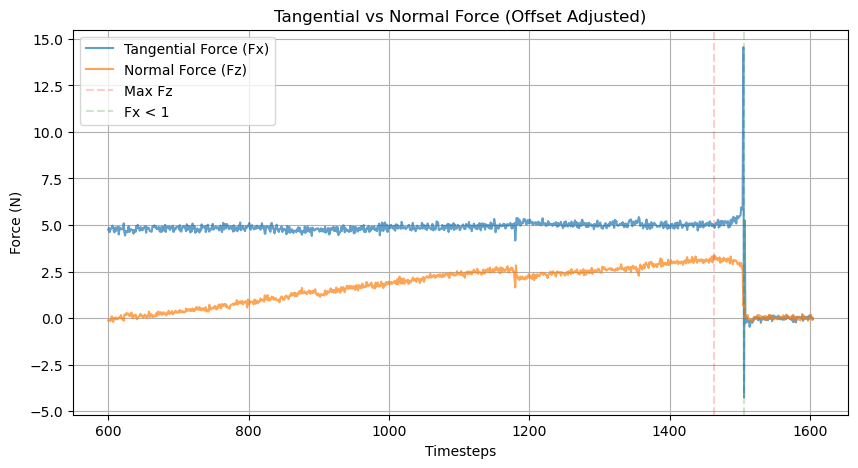

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241555.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=600, cut_2=None, avg_end=1506, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 411
Average Fx in the averaging interval [1090:1501]: 4.882266834704546
Average Fz in the averaging interval [1090:1501]: 1.2767904536857513
Maximum Fz in the plotting interval [1090:1516]: 2.3240071614583333 at timestep 1477
Time step where Fx drops below 1: 1501


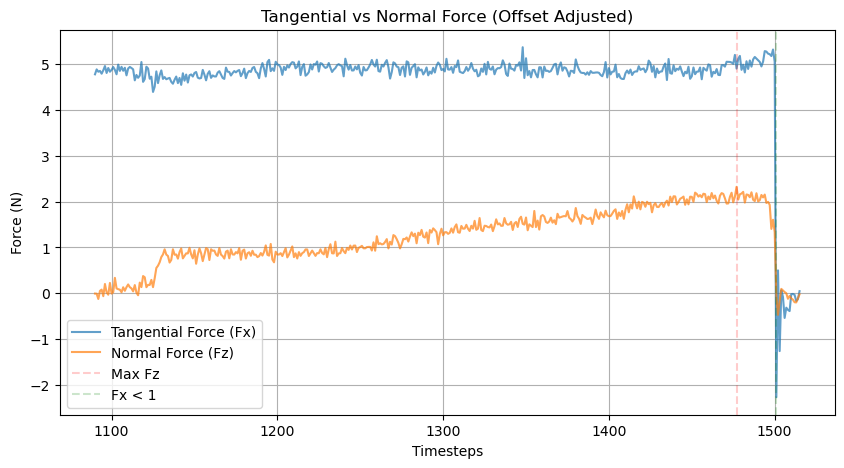

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_40_5N//log_202405241557.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=1090, cut_2=1516, avg_end=1501, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//40//MatrixBrekzie_40_stats.csv", index=False)

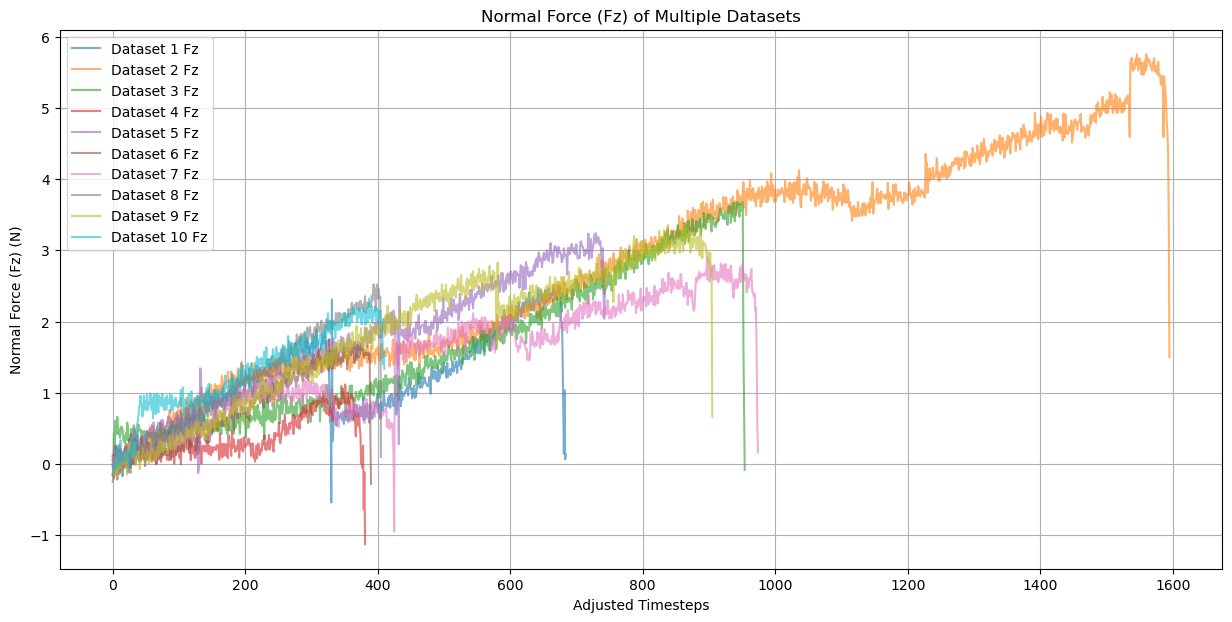

Average of maximum Fz forces: 2.9154182942708333
Standard deviation of maximum Fz forces: 1.1921658090723848
Average of average Fz forces: 1.4118610760943153
Standard deviation of average Fz forces: 0.6305354487857835
Average of average Fx forces: 4.6184424629504806
Standard deviation of average Fx forces: 0.44765718223652645


In [18]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//40//MatrixBrekzie_40"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)